# Финансовая модель дебетового продукта для молодежи

*Анализ unit-экономики и ключевых метрик продукта*

---

## Описание проекта

Модель оценивает экономику запуска дебетового продукта для студенческой аудитории. В основе расчета - развитие продукта с акцентом на долгосрочную ценность клиента (LTV) и эффективность затрат на привлечение (CAC).

**Цель**: определить финансовую целесообразность запуска продукта.

In [1]:
import pandas as pd

# 1. Таблица CAC (Customer Acquisition Cost)
cac_data = {
    'Статья затрат': [
        'Маркетинг и продвижение',
        'Выпуск и доставка карты', 
        'Вознаграждение партнерам (ВУЗам)'    
    ],
    'Стоимость (руб.)': [600, 400, 200],
    'Комментарий': [
        'Условная стоимость включения в зарплатный проект',
        'Включает стоимость чипа, пластика и дизайна',
        'Допущение о возможных бонусах учебным заведениям'
    ]
}

cac_df = pd.DataFrame(cac_data)

# 2. Таблица COGS (Cost of Goods Sold)
cogs_data = {
    'Статья затрат': [
        'Бесплатное обслуживание',
        'Яндекс.Плюс',
        'Скидки на связь',
        'Кешбэк (Высокий)',
        'Кешбэк (Базовый)',
        'Геймификация'
    ],
    'Группа клиентов': [
        'Все активные (90%)',
        'С сервисом (45%)',
        'Все активные (90%)', 
        'С сервисом (45%)',
        'Без сервиса (45%)',
        'С сервисом (45%)'
    ],
    'Стоимость (руб.))': [16, 84, 32, 25.2, 13, 2.8]
}

cogs_df = pd.DataFrame(cogs_data)

# 3. Таблица ARPU (Average Revenue Per User)
arpu_data = {
    'Источник дохода': [
        'Комиссия с мерчантов (Interchange)',
        'Проценты за кредит (овердрафт)',
        'Комиссии за доп. услуги',
        'Доход от кросс-продаж'
    ],
    'Стоимость (руб.)': [80, 25, 10, 40],
    'Комментарий': [
        '1-1,5% от оборота. Оборот 6-10 тыс.руб./мес',
        'Ставки ВТБ ~15-20% годовых.',
        'Переводы, снятие наличных в избытке и пр.',
        'Доход от продажи страховок, вкладов и тд.'
    ]
}

arpu_df = pd.DataFrame(arpu_data)

# 4. Таблица удержания
retention_data = {
    'Показатель': [
        'Средний срок жизни клиента (LifeTime)',
        'Годовой уровень оттока (Churn Rate)'
    ],
    'Рассчет': ['24 месяцев', '25%'],
    'Комментарий': [
        'Основано на данных об оттоке после окончания ВУЗа',
        'Рассчитывается как 1 / LifeTime.'
    ]
}

retention_df = pd.DataFrame(retention_data)

In [2]:
cac_df

,Статья затрат,Стоимость (руб.),Комментарий
0,Маркетинг и продвижение,600,Условная стоимость включения в зарплатный проект
1,Выпуск и доставка карты,400,"Включает стоимость чипа, пластика и дизайна"
2,Вознаграждение партнерам (ВУЗам),200,Допущение о возможных бонусах учебным заведениям


In [3]:
cogs_df

,Статья затрат,Группа клиентов,Стоимость (руб.))
0,Бесплатное обслуживание,Все активные (90%),16.0
1,Яндекс.Плюс,С сервисом (45%),84.0
2,Скидки на связь,Все активные (90%),32.0
3,Кешбэк (Высокий),С сервисом (45%),25.2
4,Кешбэк (Базовый),Без сервиса (45%),13.0
5,Геймификация,С сервисом (45%),2.8


In [4]:
arpu_df

,Источник дохода,Стоимость (руб.),Комментарий
0,Комиссия с мерчантов (Interchange),80,"1-1,5% от оборота. Оборот 6-10 тыс.руб./мес"
1,Проценты за кредит (овердрафт),25,Ставки ВТБ ~15-20% годовых.
2,Комиссии за доп. услуги,10,"Переводы, снятие наличных в избытке и пр."
3,Доход от кросс-продаж,40,"Доход от продажи страховок, вкладов и тд."


In [5]:
retention_df

,Показатель,Рассчет,Комментарий
0,Средний срок жизни клиента (LifeTime),24 месяцев,Основано на данных об оттоке после окончания ВУЗа
1,Годовой уровень оттока (Churn Rate),25%,Рассчитывается как 1 / LifeTime.


## Расчет ключевых метрик

Данные загружены в датафреймы. Кроме того, все данные были сверены с опытными финансовыми аналитиками Сбера и Т-банка которые подтвердили правдивость нашей статистики по открытым данным ВТБ. Переходим к расчету основных финансовых показателей продукта.

**Рассчитываем:**
- CAC - стоимость привлечения клиента
- COGS - операционные расходы на обслуживание
- ARPU - средний доход на пользователя
- Monthly Margin - ежемесячная маржа
- Lifetime - срок жизни клиента
- Churn Rate - уровень оттока
- LTV - пожизненная ценность клиента
- LTV/CAC - рентабельность инвестиций в привлечение
- Payback Period - период окупаемости

In [13]:
import matplotlib.pyplot as plt

# 1. Загружаем данные
cac_df = pd.DataFrame(cac_data)
cogs_df = pd.DataFrame(cogs_data)
arpu_df = pd.DataFrame(arpu_data)
retention_df = pd.DataFrame(retention_data)

# 2. Расчет ключевых метрик

# CAC
cac = cac_df['Стоимость (руб.)'].sum()

# COGS (месяц)
cogs = cogs_df['Стоимость (руб.))'].sum()

# ARPU (месяц)
arpu = arpu_df['Стоимость (руб.)'].sum()

# Monthly margin
monthly_margin = arpu - cogs

# Lifetime (в месяцах)
lifet = 24  # берём из retention таблицы

# Churn
churn_rate = 1 / lifet

# LTV
ltv = monthly_margin * lifet

# LTV / CAC
ltv_cac = ltv / cac

# Payback
payback_months = cac / monthly_margin

# 3. Сводка
metrics = pd.DataFrame({
    'Метрика': [
        'CAC', 'COGS', 'ARPU', 'Monthly Margin',
        'Lifetime (mo)', 'Churn Rate', 'LTV',
        'LTV/CAC', 'Payback (months)'
    ],
    'Значение': [
        cac, cogs, arpu, monthly_margin,
        lifet, churn_rate, ltv,
        ltv_cac, payback_months
    ]
})

metrics

,Метрика,Значение
0,CAC,1200.000000
1,COGS,173.000000
2,ARPU,155.000000
3,Monthly Margin,-18.000000
4,Lifetime (mo),24.000000
5,Churn Rate,0.041667
6,LTV,-432.000000
7,LTV/CAC,-0.360000
8,Payback (months),-66.666667


<Figure size 500x300 with 0 Axes>

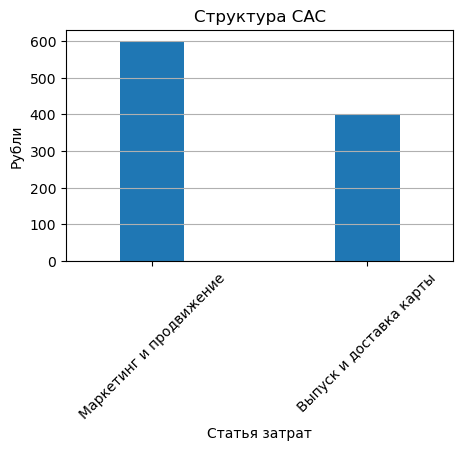

In [14]:
plt.figure(figsize=(5,3))
cac_df[:-1].plot(
    x='Статья затрат', 
    y='Стоимость (руб.)',
    kind='bar',
    legend=False,
    figsize=(5,3),
    width=0.3)
plt.title("Структура CAC")
plt.ylabel("Рубли")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

<Figure size 800x500 with 0 Axes>

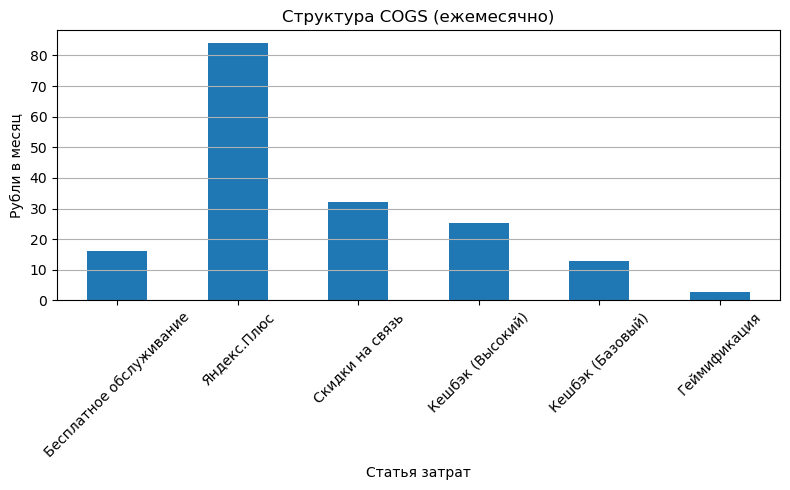

In [15]:
plt.figure(figsize=(8,5))
cogs_df.plot(
    x='Статья затрат',
    y='Стоимость (руб.))',  
    kind='bar',
    legend=False,
    figsize=(8,5))
plt.title("Структура COGS (ежемесячно)")
plt.ylabel("Рубли в месяц")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

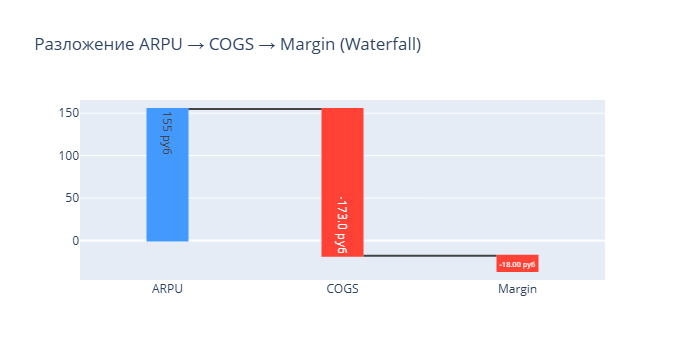

In [16]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name="ARPU breakdown", orientation="v",
    measure=["absolute", "relative", "relative"],
    x=["ARPU", "COGS", "Margin"],
    text=[f"{arpu} руб", f"-{cogs} руб", f"{monthly_margin:.2f} руб"],
    y=[arpu, -cogs, monthly_margin]))
fig.update_layout(
    title="Разложение ARPU → COGS → Margin (Waterfall)",
    waterfallgroupgap=0.7)
fig.show()

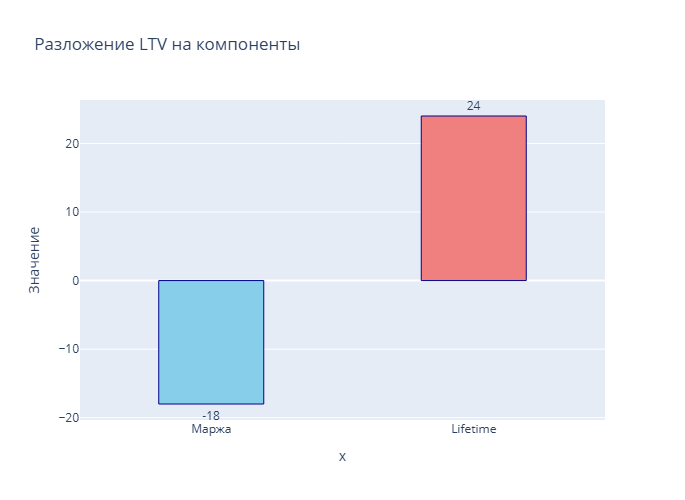

In [17]:
import plotly.express as px
import numpy as np

components = ['Маржа', 'Lifetime']
values = [monthly_margin, lifet]
fig = px.bar(
    x=components,
    y=values,
    text=values,
    title="Разложение LTV на компоненты")
fig.update_traces(
    textposition='outside',
    width=0.4,  # ← делаем столбцы тоньше (по умолчанию 0.8)
    marker=dict(
        color=['skyblue', 'lightcoral'],
        line=dict(color='darkblue', width=1)  # контур для четкости
    ))
fig.update_layout(
    height=500,  # ← делаем график выше
    showlegend=False,
    yaxis_title="Значение")
fig.show()

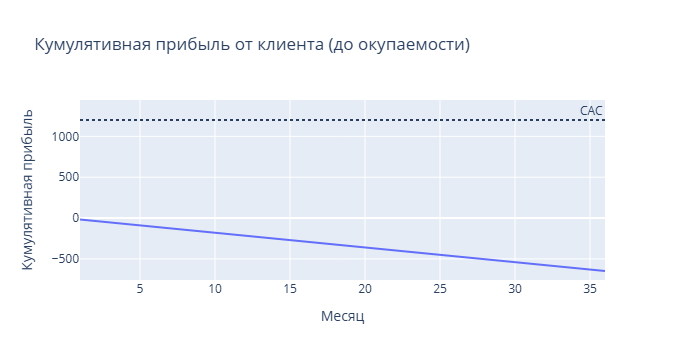

In [18]:
months = list(range(1, 37))
cum_profit = [monthly_margin * m for m in months]
fig = px.line(
    x=months, 
    y=cum_profit,
    title="Кумулятивная прибыль от клиента (до окупаемости)",
    labels={'x':'Месяц','y':'Кумулятивная прибыль'}
)
fig.add_hline(y=cac, line_dash="dot", annotation_text="CAC")
fig.show()

## Анализ результатов финансовой модели

На основе расчетов выявлены критические проблемы в экономике продукта, требующие срочного вмешательства:

### Критические показатели

**Отрицательная рентабельность**
- **LTV/CAC = -0.36** - каждый рубль привлечения приносит убыток в 0.36 рубля
- Продукт не окупает затраты на маркетинг в течение жизненного цикла клиента

**Негативная маржа**
- **Monthly Margin = -18 руб.** - ежемесячное обслуживание клиента убыточно
- ARPU (155 руб.) недостаточно для покрытия COGS (173 руб.)

**Отсутствие окупаемости**
- **Payback Period = -66.7 месяцев** - инвестиции не возвращаются
- **LTV = -432 руб.** - отрицательная пожизненная ценность клиента

### Основные проблемы

**Дисбаланс доходов и расходов**
- Высокий CAC (1200 руб.) при низком ARPU (155 руб.)
- Операционные затраты превышают доходы от клиента

**Неэффективная монетизация**
- Текущая структура доходов не покрывает базовые операционные расходы
- Отсутствует достаточный доход от дополнительных услуг и кросс-продаж

### Рекомендации по исправлению

1. **Срочное снижение CAC**
   - Оптимизация каналов привлечения
   - Пересмотр партнерских программ и вознаграждений

2. **Пересмотр монетизации**
   - Увеличение комиссионных доходов
   - Разработка платных дополнительных услуг
   - Повышение эффективности кросс-продаж

3. **Оптимизация операционных затрат**
   - Анализ и сокращение наиболее затратных статей COGS
   - Переговоры с партнерами о снижении стоимости услуг

4. **Приостановка масштабирования**
   - До выхода на положительную маржу не увеличивать бюджеты на привлечение
   - Сфокусироваться на удержании существующих клиентов

**Заключение**: Текущая модель экономически несостоятельна. Запуск продукта в представленном виде приведет к системным убыткам. Требуется фундаментальный пересмотр стратегии монетизации и оптимизация затрат.